In [1]:
import os 
import MDAnalysis as mda
import glob
import subprocess
import pandas as pd
import shutil 
import numpy as np
import pickle as pkl
from scipy import stats

os.chdir('/media/volume/Orai1_rep0/Orai1_analysis')

In [ ]:
rep1 = pkl.load(open('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/DDG.manuscript.090326/Rep-1/protein/', 'rb'))
rep2 = pkl.load(open('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/Rec-medoids/Rep-2/full/foldx/mutation.pkl', 'rb'))
rep3 = pkl.load(open('analysis/popc_0.1mCaCl2_seqfixed_180Apadding/Rec-medoids/Rep-3/full/foldx/mutation.pkl', 'rb'))

### 1. Extract DDG

In [2]:
def read_foldx_average(ave_filename, mut_list):
    modelname = os.path.basename(ave_filename).split('.')[0].split('_')[1]
    models = mutation_models(mut_list)

    records = []
    with open(ave_filename) as f:
        lines = f.readlines()
    # ---------- find header ----------
    header_line = None
    for line in lines:
        if line.startswith("Pdb"):
            header_line = line.strip()
            break
    if header_line is None:
        raise ValueError("Header line starting with 'Pdb' not found")
    # ---------- clean header names ----------
    header = header_line.split()
    # merge known multi-word columns
    merges = [
        ("total", "energy"),
        ("Backbone", "Hbond"),
        ("Sidechain", "Hbond"),
        ("Van", "der", "Waals"),
        ("Solvation", "Polar"),
        ("Solvation", "Hydrophobic"),
        ("Van", "der", "Waals", "clashes"),
        ("entropy", "sidechain"),
        ("entropy", "mainchain"),
        ("torsional", "clash"),
        ("backbone", "clash"),
        ("helix", "dipole"),
        ("water", "bridge"),
        ("electrostatic", "kon"),
        ("partial", "covalent", "bonds"),
        ("energy", "Ionisation"),
        ("Entropy", "Complex"),
    ]
    # replace merges
    header_str = header_line
    for words in merges:
        header_str = header_str.replace(" ".join(words), "_".join(words))
    header = header_str.split()
    # ---------- parse data ----------
    c = 0
    for line in lines:
        if line.strip().startswith(modelname):  # your models start with numbers
            parts = line.split()
            rec = {}
            for k, v in zip(header, parts):
                if isinstance(v, str) and v.startswith(modelname):
                    v = v.split('_')[0] + '_' + models[c][0]
                try:
                    rec[k] = float(v)
                except:
                    rec[k] = v
            c += 1
            records.append(rec)
    return records
def mutation_models(mut_list):
    with open (mut_list) as f:
        models = []
        for l in f.readlines():
            models.append(l[:-2].strip().split(','))
        f.close()
    return models 

In [5]:
### EXTRACT DDG FROM AVERAGE FILES
rep = 3
src = f'analysis/popc_0.1mCaCl2_seqfixed_180Apadding/DDG.manuscript.090326/Rep-{rep}/protein'
average = glob.glob(f'{src}/Average*')
mut_lis = f'{src}/individual_list.txt'
models = mutation_models(mut_lis)
dic = {}
for i in range(len(models)):
    m = models[i][0]
    dic[m] = {}
for fn in average:
    rec = os.path.basename(fn).split('_')[1]
    aves = read_foldx_average(fn, mut_lis)
    for m in aves:
        model = m['Pdb'].split('_')[-1]
        pdb = m['Pdb'].split('_')[0]
        dic[model][pdb] = m['total_energy'] / 6  
for m in dic:
    ave = np.average(list(dic[m].values()))
    print (f'ddG of mutation {m}: {ave: .3f} kcal/mol')
with open (f'{src}/mutation.pkl', 'wb') as f:
    pkl.dump(dic, f)
df = pd.DataFrame.from_dict(dic, orient="index")
df.index.name = "mutation"
df.to_csv(f'{src}/mutation.csv')

ddG of mutation YA208A:  1.242 kcal/mol
ddG of mutation YA208C:  1.574 kcal/mol
ddG of mutation YA208D:  2.539 kcal/mol
ddG of mutation YA208F: -0.248 kcal/mol
ddG of mutation YA208H:  1.794 kcal/mol
ddG of mutation YA208W: -0.242 kcal/mol
ddG of mutation LA223A:  2.630 kcal/mol
ddG of mutation LA223D:  4.007 kcal/mol
ddG of mutation LA223F:  1.887 kcal/mol
ddG of mutation LA223I:  0.873 kcal/mol
ddG of mutation LA223S:  3.048 kcal/mol
ddG of mutation LA226A:  3.484 kcal/mol
ddG of mutation LA226D:  5.497 kcal/mol
ddG of mutation LA226F:  4.056 kcal/mol
ddG of mutation LA226I:  2.212 kcal/mol
ddG of mutation LA226S:  4.230 kcal/mol
ddG of mutation RA231A:  0.556 kcal/mol
ddG of mutation RA231C:  0.933 kcal/mol
ddG of mutation RA231E:  1.170 kcal/mol
ddG of mutation QA233A:  0.409 kcal/mol
ddG of mutation QA233C:  0.321 kcal/mol
ddG of mutation FQ53A:  0.964 kcal/mol
ddG of mutation FQ53C:  1.262 kcal/mol
ddG of mutation FQ53D:  1.454 kcal/mol
ddG of mutation FQ53H:  1.117 kcal/mol
ddG 

In [6]:
df

,1951,4853,1090,2380,4596,3603,1746,2197,0579,4696,0057,0205,0290
mutation,,,,,,,,,,,,,
YA208A,1.859267,1.415157,0.777003,1.515045,0.360615,1.234620,1.338638,1.789283,1.100912,1.310047,1.936233,0.608392,0.896642
YA208C,2.109517,1.888333,1.078512,1.923683,0.788340,1.551182,1.723467,2.029050,1.430970,1.655928,2.254817,0.827397,1.203695
YA208D,3.096867,2.421100,2.030167,2.723767,2.474067,2.503750,2.530683,2.960400,2.587567,2.405800,3.126217,1.673333,2.468717
YA208F,-0.193060,-0.264025,-0.658793,-0.284612,-0.239902,-0.115976,-0.291430,-0.317777,-0.038494,-0.312293,-0.334350,-0.118669,-0.058711
YA208H,2.041333,1.979467,1.927033,2.066383,1.008243,1.742467,1.894133,1.872850,2.284683,1.311350,2.135317,1.604555,1.448867
YA208W,0.045643,-0.287878,-0.531933,-0.156012,-0.734172,-0.377858,0.131948,-0.058935,-0.408210,-0.428762,0.274058,-0.319908,-0.298970
LA223A,3.028833,2.452017,2.531033,2.609533,2.505683,2.616633,2.719883,3.220900,2.201133,2.717383,3.172667,2.418550,2.001417
LA223D,4.718467,4.047017,3.907617,4.021450,3.980233,4.008633,4.067383,4.603767,3.327733,3.865950,4.771867,3.612367,3.162983
LA223F,2.941083,2.121583,1.666115,1.276113,1.564713,1.826350,1.122500,3.048433,1.251787,1.529570,3.037967,1.660612,1.486587


In [7]:
"""
FoldX per-chain ddG extraction, grouped by Orai1 / CADa / CADb / CAD.

Key point: FoldX reports total_energy as the SUM over all chains mutated in a
given line of individual_list.txt. The divisor is therefore read from the line
itself (6 for most, 12 for the all-CAD lines), not hardcoded.
"""

import os
import re
import glob
import numpy as np
import pandas as pd

# ---------------------------------------------------------------- chain groups
ORAI1 = set('ABCDEF')          # Orai1 subunits
CADA  = set('QGIKMO')          # CAD, directly binding an Orai1 subunit
CADB  = set('HJLNPR')          # CAD, neighbouring (not directly binding)

REP_LABELS = ['Rep 1', 'Rep 2', 'Rep 3']
SRC_BASE = 'analysis/popc_0.1mCaCl2_seqfixed_180Apadding/DDG.manuscript.090326/'


# ---------------------------------------------------------------- parsing
def parse_mut(s):
    """'LA223D' -> {'res':'L', 'chain':'A', 'pos':223, 'mut':'D'}"""
    m = re.match(r'([A-Z])([A-Z])(\d+)([A-Z])$', s.strip())
    if not m:
        return None
    return {'res': m.group(1), 'chain': m.group(2),
            'pos': int(m.group(3)), 'mut': m.group(4)}


def read_mut_list(path):
    """
    Parse individual_list.txt.
    Returns a list of (label, group, n_chains) in file order -- the order the
    rows appear in each Average_*.fxout file.
    """
    entries = []
    with open(path) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line or line.startswith('~'):
                continue

            muts = [parse_mut(x) for x in line.split(',')]
            muts = [m for m in muts if m]
            if not muts:
                continue

            chains = {m['chain'] for m in muts}
            if chains <= ORAI1:
                group = 'Orai1'
            elif chains <= CADA:
                group = 'CADa'
            elif chains <= CADB:
                group = 'CADb'
            else:
                group = 'CAD'          # spans both CAD sets

            label = f"{muts[0]['res']}{muts[0]['pos']}{muts[0]['mut']}"
            entries.append((label, group, len(muts)))
    return entries


def read_average(fn):
    """Yield (row_index, total_energy) for each data row of an Average_*.fxout."""
    with open(fn) as f:
        lines = f.readlines()

    hdr = next(l for l in lines if l.startswith('Pdb'))
    merges = [("total", "energy"), ("Backbone", "Hbond"), ("Sidechain", "Hbond"),
              ("Van", "der", "Waals", "clashes"), ("Van", "der", "Waals"),
              ("Solvation", "Polar"), ("Solvation", "Hydrophobic"),
              ("entropy", "sidechain"), ("entropy", "mainchain"),
              ("torsional", "clash"), ("backbone", "clash"), ("helix", "dipole"),
              ("water", "bridge"), ("electrostatic", "kon"),
              ("partial", "covalent", "bonds"), ("energy", "Ionisation"),
              ("Entropy", "Complex")]
    for w in merges:
        hdr = hdr.replace(" ".join(w), "_".join(w))
    ti = hdr.split().index('total_energy')

    modelname = os.path.basename(fn).split('.')[0].split('_')[1]
    i = 0
    for l in lines:
        if l.strip().startswith(modelname):
            yield i, float(l.split()[ti])
            i += 1


# ---------------------------------------------------------------- extraction
def extract_rep(rep, src_base=SRC_BASE):
    """
    -> {group: {label: {receptor: per_chain_ddG}}}

    per_chain_ddG = total_energy / n_chains_in_that_line
    """
    src = f'{src_base}/Rep-{rep}/protein'
    entries = read_mut_list(f'{src}/individual_list.txt')

    out = {}
    for fn in sorted(glob.glob(f'{src}/Average*')):
        receptor = os.path.basename(fn).split('.')[0].split('_')[1]
        for i, total in read_average(fn):
            if i >= len(entries):
                continue
            label, group, n = entries[i]
            out.setdefault(group, {}).setdefault(label, {})[receptor] = total / n
    return out


# ---------------------------------------------------------------- statistics
def summarise(reps, groups=('Orai1', 'CADa', 'CADb', 'CAD')):
    """
    Hierarchical: receptors -> replicate mean -> mean +/- SEM across replicates.
    Returns a tidy DataFrame with the individual replicate means kept as columns.
    """
    rows = []
    for group in groups:
        labels = sorted({l for r in reps for l in r.get(group, {})})
        for label in labels:
            rep_means, per_rep = [], {}
            for k, r in enumerate(reps):
                if label in r.get(group, {}):
                    m = float(np.mean(list(r[group][label].values())))
                    rep_means.append(m)
                    per_rep[REP_LABELS[k]] = m

            if not rep_means:
                continue

            n = len(rep_means)
            sd = float(np.std(rep_means, ddof=1)) if n > 1 else np.nan
            row = {'Group': group,
                   'Mutation': label,
                   'ddG': float(np.mean(rep_means)),
                   'SD': sd,
                   'SEM': sd / np.sqrt(n) if n > 1 else np.nan,
                   'n_rep': n}
            row.update(per_rep)
            rows.append(row)

    cols = ['Group', 'Mutation', 'ddG', 'SD', 'SEM', 'n_rep'] + REP_LABELS
    df = pd.DataFrame(rows)
    return df[[c for c in cols if c in df.columns]]

save_dir = 'Manuscript/data'

# ---------------------------------------------------------------- main
if __name__ == '__main__':
    reps = [extract_rep(1), extract_rep(2), extract_rep(3)]

    df = summarise(reps)
    df.to_csv(f'{save_dir}/ddG_per_chain_by_group.csv', index=False)
    print(df.to_string(index=False))
    print('\nSaved: ddG_per_chain_by_group.csv')

    # Subset of interest: L223 (Orai1 L273) and I68 (CAD I409)
    sub = df[df['Mutation'].str.match(r'^[LI](223|68)')]
    if not sub.empty:
        print('\nMutations of interest')
        print(sub.to_string(index=False))
        sub.to_csv(f'{save_dir}/ddG_L223_I68.csv', index=False)
        print(f'Saved: {save_dir}/ddG_L223_I68.csv')

Group Mutation       ddG       SD      SEM  n_rep     Rep 1     Rep 2     Rep 3
Orai1    L223A  2.750963 0.108754 0.062789      3  2.841761  2.780691  2.630436
Orai1    L223D  4.189444 0.166050 0.095869      3  4.332478  4.228511  4.007344
Orai1    L223F  2.002606 0.113835 0.065723      3  2.114787  2.005845  1.887186
Orai1    L223I  0.869188 0.047585 0.027473      3  0.819738  0.914659  0.873168
Orai1    L223S  3.152045 0.113594 0.065583      3  3.273361  3.134578  3.048197
Orai1    L226A  3.459193 0.022103 0.012761      3  3.449778  3.443358  3.484445
Orai1    L226D  5.458440 0.033208 0.019173      3  5.442580  5.436137  5.496605
Orai1    L226F  3.854383 0.209135 0.120744      3  3.869087  3.638283  4.055778
Orai1    L226I  1.965200 0.234516 0.135398      3  1.745374  1.938163  2.212063
Orai1    L226S  4.223880 0.037084 0.021411      3  4.257367  4.184023  4.230251
Orai1    Q233A  0.513283 0.093482 0.053972      3  0.542508  0.588661  0.408680
Orai1    Q233C  0.400625 0.084569 0.0488

#### 1. FIG6F

Saved: Manuscript/Raw/Fig6F/ddG_violin_selected.png


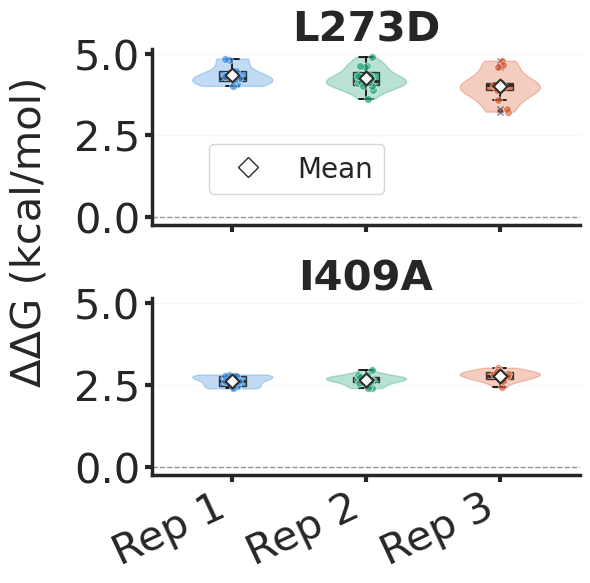

Mutation Group   Rep 1    Rep 2    Rep 3     Mean       SD
   L273D Orai1 4.34433 4.242484 4.008049 4.198288 0.172442
   I409A  CADa 2.62500 2.648594 2.775736 2.683110 0.081079


In [116]:
"""
Per-replicate ΔΔG distributions for a selected set of mutations.

One panel per mutation; within a panel, one violin+box per replicate, with the
individual receptor (medoid) values overlaid as points.

Renumbering:
    Orai1 construct index + 50  -> Orai1 full-length
    CAD   construct index + 341 -> CAD (STIM1) full-length
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# ── settings ──────────────────────────────────────────────────────────────────
ft = 30                                   # global font size

SELECTION = ['L223D', 'I68A']             # -> L273D, I409A; plotted in this order
GROUP_OVERRIDE = {}                       # e.g. {'E29A': 'CADa'} when ambiguous

NCOLS = 1                                 # 2 mutations -> 2 rows x 1 column
OFFSETS = {'Orai1': 50, 'CADa': 341, 'CADb': 341, 'CAD': 341}

YTICK_STEP = 2.5                          # -> ..., 0, 2.5, 5, ...

rep_labels = ['Rep 1', 'Rep 2', 'Rep 3']
REP_COLORS = ['#378ADD', '#1D9E75', '#D85A30']

OUT_PNG = 'Manuscript/Raw/Fig6F/ddG_violin_selected.png'


# ── helpers ───────────────────────────────────────────────────────────────────
def renumber(label, group):
    """'L223D' + Orai1 -> 'L273D';  'I68A' + CAD* -> 'I409A'."""
    m = re.match(r'([A-Z])(\d+)([A-Z])$', label)
    if not m:
        return label
    return f"{m.group(1)}{int(m.group(2)) + OFFSETS.get(group, 0)}{m.group(3)}"


def resolve_group(replicates, label, override=None):
    """Which group does this label live in? None if absent."""
    override = override or {}
    if label in override:
        return override[label]
    groups = [g for rep in replicates for g, d in rep.items() if label in d]
    if not groups:
        return None
    uniq = list(dict.fromkeys(groups))
    if len(uniq) > 1:
        print(f"  [warn] {label} found in {', '.join(uniq)}; using '{uniq[0]}'. "
              f"Set GROUP_OVERRIDE['{label}'] to choose.")
    return uniq[0]


def collect(replicates, label, group):
    """-> list of arrays, one per replicate (values across receptors)."""
    out = []
    for rep in replicates:
        vals = rep.get(group, {}).get(label, {})
        out.append(np.array(list(vals.values()), dtype=float))
    return out


# ── main ──────────────────────────────────────────────────────────────────────
replicates = [extract_rep(1), extract_rep(2), extract_rep(3)]
n_reps = len(replicates)
x_pos = np.arange(n_reps)

# resolve each requested mutation to (label, group, data)
panels = []
for label in SELECTION:
    group = resolve_group(replicates, label, GROUP_OVERRIDE)
    if group is None:
        print(f"  [warn] {label}: not found -- skipped")
        continue
    data = collect(replicates, label, group)
    if all(len(d) == 0 for d in data):
        print(f"  [warn] {label}: no values -- skipped")
        continue
    panels.append({'label': label, 'group': group,
                   'title': renumber(label, group), 'data': data})

if not panels:
    raise SystemExit('None of the requested mutations were found.')

nrows = int(np.ceil(len(panels) / NCOLS))
fig, axes = plt.subplots(nrows, NCOLS, figsize=(6, 3 * nrows),
                         sharey=True, squeeze=False)
axes_flat = axes.flatten()

for i, p in enumerate(panels):
    ax = axes_flat[i]
    data = p['data']

    # violins only for replicates that actually have >1 value
    ok = [k for k, d in enumerate(data) if len(d) > 1]
    if ok:
        parts = ax.violinplot([data[k] for k in ok], positions=x_pos[ok],
                              widths=0.6, showmeans=False,
                              showmedians=False, showextrema=False)
        for pc, k in zip(parts['bodies'], ok):
            pc.set_facecolor(REP_COLORS[k])
            pc.set_alpha(0.3)
            pc.set_edgecolor(REP_COLORS[k])

    # boxplot overlay
    nonempty = [k for k, d in enumerate(data) if len(d) > 0]
    if nonempty:
        bp = ax.boxplot([data[k] for k in nonempty], positions=x_pos[nonempty],
                        widths=0.2, patch_artist=True,
                        medianprops=dict(color='#2C2C2A', linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.2),
                        flierprops=dict(marker='x', markersize=5, alpha=0.5),
                        zorder=3)
        for patch, k in zip(bp['boxes'], nonempty):
            patch.set_facecolor(REP_COLORS[k])
            patch.set_alpha(0.7)

    # individual receptor values
    rng = np.random.default_rng(0)          # fixed seed -> reproducible jitter
    for k, vals in enumerate(data):
        if len(vals) == 0:
            continue
        jitter = (rng.random(len(vals)) - 0.5) * 0.12
        ax.scatter(np.full(len(vals), x_pos[k]) + jitter, vals,
                   color=REP_COLORS[k], s=30, alpha=0.7, zorder=4,
                   edgecolors='white', linewidths=0.5)

    # mean marker
    for k, vals in enumerate(data):
        if len(vals) == 0:
            continue
        ax.scatter(x_pos[k], vals.mean(), marker='D', s=50, color='white',
                   edgecolors='#2C2C2A', linewidths=1.5, zorder=5)

    ax.set_title(f"{p['title']}", fontsize=ft, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=ft, width=3., length=5.)
    ax.set_xticks(x_pos)
    is_bottom_row = i >= len(panels) - NCOLS
    if is_bottom_row:
        ax.set_xticklabels(rep_labels, fontsize=ft, rotation=25, ha='right')
    else:
        ax.set_xticklabels([])
    ax.set_xlim(-0.6, n_reps - 0.4)
    ax.yaxis.set_major_locator(MultipleLocator(YTICK_STEP))
    ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.4)
    ax.grid(axis='y', alpha=0.15, zorder=0)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_linewidth(2.5)

# hide unused panels
for j in range(len(panels), len(axes_flat)):
    axes_flat[j].axis('off')

# mean-marker key, on the top panel
legend_elements = []
legend_elements.append(
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='white',
               markeredgecolor='#2C2C2A', markersize=10, label='Mean', linestyle='None'))

target_ax = axes[0, 0]
target_ax.legend(handles=legend_elements, loc='lower left', ncol=1,
                 fontsize=ft-10, frameon=True, bbox_to_anchor=(0.1, 0.1))

# single y label, centred across both rows
fig.supylabel('ΔΔG (kcal/mol)', fontsize=ft, x=0.02, y = 0.6)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches='tight', dpi=300)
print(f'Saved: {OUT_PNG}')
plt.show()

# ── numbers behind the figure ─────────────────────────────────────────────────
rows = []
for p in panels:
    rep_means = [d.mean() for d in p['data'] if len(d)]
    rows.append({'Mutation': p['title'], 'Group': p['group'],
                 **{rep_labels[k]: (d.mean() if len(d) else np.nan)
                    for k, d in enumerate(p['data'])},
                 'Mean': np.mean(rep_means),
                 'SD': np.std(rep_means, ddof=1) if len(rep_means) > 1 else np.nan})
print(pd.DataFrame(rows).to_string(index=False))

Saved: Manuscript/Raw/Fig6F/ddG_violin_selected.png


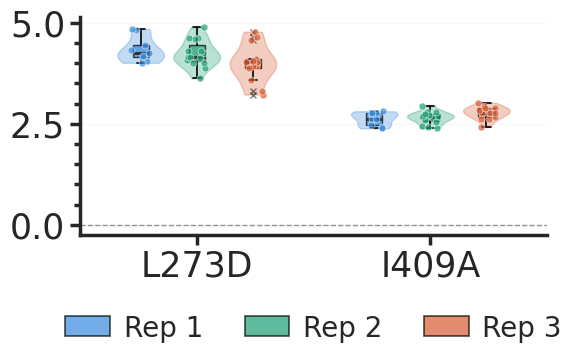

Mutation Group   Rep 1    Rep 2    Rep 3     Mean       SD
   L273D Orai1 4.34433 4.242484 4.008049 4.198288 0.172442
   I409A  CADa 2.62500 2.648594 2.775736 2.683110 0.081079


In [138]:
"""
ΔΔG distributions for a selected set of mutations, single panel.

One x position per mutation; three tightly dodged violin+box pairs per
position, one per replicate, with individual receptor values overlaid.

Renumbering:
    Orai1 construct index + 50  -> Orai1 full-length
    CAD   construct index + 341 -> CAD (STIM1) full-length
"""

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator

# ── settings ──────────────────────────────────────────────────────────────────
ft = 25                                   # global font size

SELECTION = ['L223D', 'I68A']             # -> L273D, I409A; left to right
GROUP_OVERRIDE = {}                       # e.g. {'E29A': 'CADa'} when ambiguous

OFFSETS = {'Orai1': 50, 'CADa': 341, 'CADb': 341, 'CAD': 341}

YTICK_STEP = 2.5                          # -> ..., 0, 2.5, 5, ...

DODGE = 0.24                              # spacing between replicates
VIOLIN_W = 0.20                           # violin width
BOX_W = 0.07                              # box width

rep_labels = ['Rep 1', 'Rep 2', 'Rep 3']
REP_COLORS = ['#378ADD', '#1D9E75', '#D85A30']

OUT_PNG = 'Manuscript/Raw/Fig6F/ddG_violin_selected.png'


# ── helpers ───────────────────────────────────────────────────────────────────
def renumber(label, group):
    """'L223D' + Orai1 -> 'L273D';  'I68A' + CAD* -> 'I409A'."""
    m = re.match(r'([A-Z])(\d+)([A-Z])$', label)
    if not m:
        return label
    return f"{m.group(1)}{int(m.group(2)) + OFFSETS.get(group, 0)}{m.group(3)}"


def resolve_group(replicates, label, override=None):
    """Which group does this label live in? None if absent."""
    override = override or {}
    if label in override:
        return override[label]
    groups = [g for rep in replicates for g, d in rep.items() if label in d]
    if not groups:
        return None
    uniq = list(dict.fromkeys(groups))
    if len(uniq) > 1:
        print(f"  [warn] {label} found in {', '.join(uniq)}; using '{uniq[0]}'. "
              f"Set GROUP_OVERRIDE['{label}'] to choose.")
    return uniq[0]


def collect(replicates, label, group):
    """-> list of arrays, one per replicate (values across receptors)."""
    out = []
    for rep in replicates:
        vals = rep.get(group, {}).get(label, {})
        out.append(np.array(list(vals.values()), dtype=float))
    return out


# ── main ──────────────────────────────────────────────────────────────────────
replicates = [extract_rep(1), extract_rep(2), extract_rep(3)]
n_reps = len(replicates)

# resolve each requested mutation
groups_plotted = []
for label in SELECTION:
    group = resolve_group(replicates, label, GROUP_OVERRIDE)
    if group is None:
        print(f"  [warn] {label}: not found -- skipped")
        continue
    data = collect(replicates, label, group)
    if all(len(d) == 0 for d in data):
        print(f"  [warn] {label}: no values -- skipped")
        continue
    groups_plotted.append({'label': label, 'group': group,
                           'title': renumber(label, group), 'data': data})

if not groups_plotted:
    raise SystemExit('None of the requested mutations were found.')

n_mut = len(groups_plotted)
centres = np.arange(n_mut)                       # one x position per mutation
offsets = (np.arange(n_reps) - (n_reps - 1) / 2) * DODGE

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

rng = np.random.default_rng(0)                   # reproducible jitter

for m, p in enumerate(groups_plotted):
    data = p['data']
    pos = centres[m] + offsets

    # violins
    ok = [k for k, d in enumerate(data) if len(d) > 1]
    if ok:
        parts = ax.violinplot([data[k] for k in ok], positions=pos[ok],
                              widths=VIOLIN_W, showmeans=False,
                              showmedians=False, showextrema=False)
        for pc, k in zip(parts['bodies'], ok):
            pc.set_facecolor(REP_COLORS[k])
            pc.set_alpha(0.3)
            pc.set_edgecolor(REP_COLORS[k])

    # boxes
    nonempty = [k for k, d in enumerate(data) if len(d) > 0]
    if nonempty:
        bp = ax.boxplot([data[k] for k in nonempty], positions=pos[nonempty],
                        widths=BOX_W, patch_artist=True,
                        medianprops=dict(color='#2C2C2A', linewidth=2),
                        whiskerprops=dict(linewidth=1.2),
                        capprops=dict(linewidth=1.2),
                        flierprops=dict(marker='x', markersize=5, alpha=0.5),
                        zorder=3)
        for patch, k in zip(bp['boxes'], nonempty):
            patch.set_facecolor(REP_COLORS[k])
            patch.set_alpha(0.7)

    # individual receptor values
    for k, vals in enumerate(data):
        if len(vals) == 0:
            continue
        jitter = (rng.random(len(vals)) - 0.5) * (DODGE * 0.35)
        ax.scatter(np.full(len(vals), pos[k]) + jitter, vals,
                   color=REP_COLORS[k], s=25, alpha=0.7, zorder=4,
                   edgecolors='white', linewidths=0.5)

    # mean marker
    # mean marker

# ── axes ──────────────────────────────────────────────────────────────────────
ax.set_xticks(centres)
ax.set_xticklabels([p['title'] for p in groups_plotted], fontsize=ft)
ax.set_xlim(-0.5, n_mut - 0.5)

#ax.set_ylabel('ΔΔG (kcal/mol)', fontsize=ft)
ax.yaxis.set_major_locator(MultipleLocator(YTICK_STEP))
ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.4)

ax.minorticks_on()
ax.tick_params(axis='x', which = 'minor', bottom=False, top=False)
ax.tick_params(axis='both', which='major', labelsize=ft, width=2.5, length=7)
ax.tick_params(axis='y', which = 'minor', width=2.5, length=4)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2.5)
ax.grid(axis='y', alpha=0.15, zorder=0)

# ── legend ────────────────────────────────────────────────────────────────────
handles = [mpatches.Patch(facecolor=REP_COLORS[k], alpha=0.7,
                          edgecolor='black', linewidth=1.2,
                          label=rep_labels[k])
           for k in range(n_reps)]

ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.25),
          ncol=len(handles), fontsize=ft-5, frameon=False,
          columnspacing=1.5, handlelength=1.6, handletextpad=0.5)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches='tight', dpi=600)
print(f'Saved: {OUT_PNG}')
plt.show()

# ── numbers behind the figure ─────────────────────────────────────────────────
rows = []
for p in groups_plotted:
    rep_means = [d.mean() for d in p['data'] if len(d)]
    rows.append({'Mutation': p['title'], 'Group': p['group'],
                 **{rep_labels[k]: (d.mean() if len(d) else np.nan)
                    for k, d in enumerate(p['data'])},
                 'Mean': np.mean(rep_means),
                 'SD': np.std(rep_means, ddof=1) if len(rep_means) > 1 else np.nan})
print(pd.DataFrame(rows).to_string(index=False))

#### 2. FIG7

In [68]:
"""
FoldX per-chain ddG extraction, grouped by Orai1 / CADa / CADb / CAD.

Key point: FoldX reports total_energy as the SUM over all chains mutated in a
given line of individual_list.txt. The divisor is therefore read from the line
itself (6 for most, 12 for the all-CAD lines), not hardcoded.
"""

import os
import re
import glob
import numpy as np
import pandas as pd

# ---------------------------------------------------------------- chain groups
ORAI1 = set('ABCDEF')          # Orai1 subunits
CADA  = set('QGIKMO')          # CAD, directly binding an Orai1 subunit
CADB  = set('HJLNPR')          # CAD, neighbouring (not directly binding)

REP_LABELS = ['Rep 1', 'Rep 2', 'Rep 3']
SRC_BASE = 'analysis/popc_0.1mCaCl2_seqfixed_180Apadding/Rec-medoids'


# ---------------------------------------------------------------- parsing
def parse_mut(s):
    """'LA223D' -> {'res':'L', 'chain':'A', 'pos':223, 'mut':'D'}"""
    m = re.match(r'([A-Z])([A-Z])(\d+)([A-Z])$', s.strip())
    if not m:
        return None
    return {'res': m.group(1), 'chain': m.group(2),
            'pos': int(m.group(3)), 'mut': m.group(4)}


def read_mut_list(path):
    """
    Parse individual_list.txt.
    Returns a list of (label, group, n_chains) in file order -- the order the
    rows appear in each Average_*.fxout file.
    """
    entries = []
    with open(path) as f:
        for line in f:
            line = line.strip().rstrip(';')
            if not line or line.startswith('~'):
                continue

            muts = [parse_mut(x) for x in line.split(',')]
            muts = [m for m in muts if m]
            if not muts:
                continue

            chains = {m['chain'] for m in muts}
            if chains <= ORAI1:
                group = 'Orai1'
            elif chains <= CADA:
                group = 'CADa'
            elif chains <= CADB:
                group = 'CADb'
            else:
                group = 'CAD'          # spans both CAD sets

            label = f"{muts[0]['res']}{muts[0]['pos']}{muts[0]['mut']}"
            entries.append((label, group, len(muts)))
    return entries


def read_average(fn):
    """Yield (row_index, total_energy) for each data row of an Average_*.fxout."""
    with open(fn) as f:
        lines = f.readlines()

    hdr = next(l for l in lines if l.startswith('Pdb'))
    merges = [("total", "energy"), ("Backbone", "Hbond"), ("Sidechain", "Hbond"),
              ("Van", "der", "Waals", "clashes"), ("Van", "der", "Waals"),
              ("Solvation", "Polar"), ("Solvation", "Hydrophobic"),
              ("entropy", "sidechain"), ("entropy", "mainchain"),
              ("torsional", "clash"), ("backbone", "clash"), ("helix", "dipole"),
              ("water", "bridge"), ("electrostatic", "kon"),
              ("partial", "covalent", "bonds"), ("energy", "Ionisation"),
              ("Entropy", "Complex")]
    for w in merges:
        hdr = hdr.replace(" ".join(w), "_".join(w))
    ti = hdr.split().index('total_energy')

    modelname = os.path.basename(fn).split('.')[0].split('_')[1]
    i = 0
    for l in lines:
        if l.strip().startswith(modelname):
            yield i, float(l.split()[ti])
            i += 1


# ---------------------------------------------------------------- extraction
def extract_rep(rep, src_base=SRC_BASE):
    """
    -> {group: {label: {receptor: per_chain_ddG}}}

    per_chain_ddG = total_energy / n_chains_in_that_line
    """
    src = f'{src_base}/Rep-{rep}/full/foldx'
    entries = read_mut_list(f'{src}/individual_list.txt')

    out = {}
    for fn in sorted(glob.glob(f'{src}/Average*')):
        receptor = os.path.basename(fn).split('.')[0].split('_')[1]
        for i, total in read_average(fn):
            if i >= len(entries):
                continue
            label, group, n = entries[i]
            out.setdefault(group, {}).setdefault(label, {})[receptor] = total / n
    return out


# ---------------------------------------------------------------- statistics
def summarise(reps, groups=('Orai1', 'CADa', 'CADb', 'CAD')):
    """
    Hierarchical: receptors -> replicate mean -> mean +/- SEM across replicates.
    Returns a tidy DataFrame with the individual replicate means kept as columns.
    """
    rows = []
    for group in groups:
        labels = sorted({l for r in reps for l in r.get(group, {})})
        for label in labels:
            rep_means, per_rep = [], {}
            for k, r in enumerate(reps):
                if label in r.get(group, {}):
                    m = float(np.mean(list(r[group][label].values())))
                    rep_means.append(m)
                    per_rep[REP_LABELS[k]] = m

            if not rep_means:
                continue

            n = len(rep_means)
            sd = float(np.std(rep_means, ddof=1)) if n > 1 else np.nan
            row = {'Group': group,
                   'Mutation': label,
                   'ddG': float(np.mean(rep_means)),
                   'SD': sd,
                   'SEM': sd / np.sqrt(n) if n > 1 else np.nan,
                   'n_rep': n}
            row.update(per_rep)
            rows.append(row)

    cols = ['Group', 'Mutation', 'ddG', 'SD', 'SEM', 'n_rep'] + REP_LABELS
    df = pd.DataFrame(rows)
    return df[[c for c in cols if c in df.columns]]

save_dir = 'Manuscript/data'

# ---------------------------------------------------------------- main
if __name__ == '__main__':
    reps = [extract_rep(1), extract_rep(2), extract_rep(3)]

    df = summarise(reps)
    df.to_csv(f'{save_dir}/ddG_per_chain_by_group.csv', index=False)
    print(df.to_string(index=False))
    print('\nSaved: ddG_per_chain_by_group.csv')

    # Subset of interest: L223 (Orai1 L273) and I68 (CAD I409)
    sub = df[df['Mutation'].str.match(r'^[LI](208)')]
    if not sub.empty:
        print('\nMutations of interest')
        print(sub.to_string(index=False))
        sub.to_csv(f'{save_dir}/ddG_Y258.csv', index=False)
        print(f'Saved: {save_dir}/ddG_Y258.csv')

Group Mutation       ddG       SD      SEM  n_rep     Rep 1     Rep 2     Rep 3
Orai1    L223A  2.804145 0.129832 0.074959      3  2.907854  2.846044  2.658537
Orai1    L223D  4.301006 0.229056 0.132245      3  4.484813  4.373808  4.044397
Orai1    L223F  2.514582 0.324362 0.187270      3  2.885536  2.373886  2.284324
Orai1    L223I  1.010455 0.045566 0.026307      3  0.968281  1.058786  1.004296
Orai1    L223S  3.350623 0.124803 0.072055      3  3.482928  3.333942  3.234999
Orai1    L226A  3.550556 0.032328 0.018664      3  3.563059  3.513844  3.574765
Orai1    L226D  5.523190 0.013106 0.007567      3  5.521337  5.511109  5.537123
Orai1    L226F  3.953106 0.514909 0.297283      3  4.163822  3.366260  4.329235
Orai1    L226I  2.092134 0.171739 0.099153      3  1.938536  2.060306  2.277560
Orai1    L226S  4.322039 0.070181 0.040519      3  4.380185  4.244082  4.341849
Orai1    Y208A  1.624451 0.077441 0.044711      3  1.569872  1.713084  1.590398
Orai1    Y208C  1.949861 0.130016 0.0750

Saved: Manuscript/Raw/Fig7/ddG_Y208_by_replicate.png


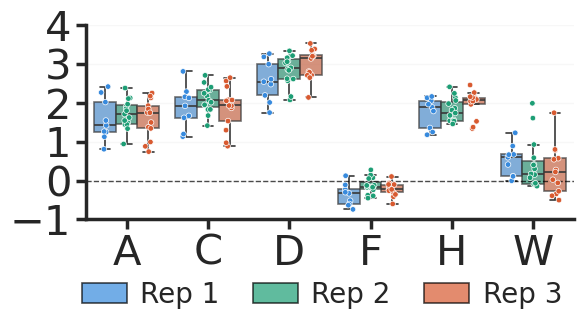

                     mean       std  count
Full  Replicate                           
Y258A Rep 1      1.569872  0.549748      9
      Rep 2      1.713084  0.366270     15
      Rep 3      1.590398  0.499824     13
Y258C Rep 1      1.882001  0.538728      9
      Rep 2      2.099767  0.342729     15
      Rep 3      1.867815  0.558955     13
Y258D Rep 1      2.562635  0.523368      9
      Rep 2      2.853224  0.377841     15
      Rep 3      2.993063  0.389625     13
Y258F Rep 1     -0.373034  0.279165      9
      Rep 2     -0.134460  0.201837     15
      Rep 3     -0.222789  0.178750     13
Y258H Rep 1      1.754529  0.389359      9
      Rep 2      1.807767  0.300633     15
      Rep 3      1.971314  0.342355     13
Y258W Rep 1      0.520150  0.406009      9
      Rep 2      0.407013  0.644480     15
      Rep 3      0.260234  0.631332     13


In [111]:
"""
ΔΔG distribution for a selected set of mutations, grouped by replicate.

One x position per mutation, three boxes per position (one per replicate),
built from the per-chain ddG values returned by extract_rep().

Renumbering:
    Orai1 construct index + 50  -> Orai1 full-length
    CAD   construct index + 341 -> CAD (STIM1) full-length
"""

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import seaborn as sns

# ── settings ──────────────────────────────────────────────────────────────────
ft = 30                                   # global font size

SELECTION = ['Y208A', 'Y208C', 'Y208D', 'Y208F', 'Y208H', 'Y208W']
GROUP_OVERRIDE = {}                       # e.g. {'E29A': 'CADa'} when ambiguous

OFFSETS = {'Orai1': 50, 'CADa': 341, 'CADb': 341, 'CAD': 341}

rep_labels = ['Rep 1', 'Rep 2', 'Rep 3']
REP_COLORS = ['#378ADD', '#1D9E75', '#D85A30']

SHOW_POINTS = True                        # overlay individual receptor values

OUT_DIR = 'Manuscript/Raw/Fig7'
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PNG = os.path.join(OUT_DIR, 'ddG_Y208_by_replicate.png')


# ── helpers ───────────────────────────────────────────────────────────────────
def renumber(label, group):
    """'Y208A' + Orai1 -> 'Y258A';  'I68A' + CAD* -> 'I409A'."""
    m = re.match(r'([A-Z])(\d+)([A-Z])$', label)
    if not m:
        return label
    return f"{m.group(1)}{int(m.group(2)) + OFFSETS.get(group, 0)}{m.group(3)}"


def resolve_group(replicates, label, override=None):
    """Which group does this label live in? None if absent."""
    override = override or {}
    if label in override:
        return override[label]
    groups = [g for rep in replicates for g, d in rep.items() if label in d]
    if not groups:
        return None
    uniq = list(dict.fromkeys(groups))
    if len(uniq) > 1:
        print(f"  [warn] {label} found in {', '.join(uniq)}; using '{uniq[0]}'. "
              f"Set GROUP_OVERRIDE['{label}'] to choose.")
    return uniq[0]


# ── build the long-form table ─────────────────────────────────────────────────
replicates = [extract_rep(1), extract_rep(2), extract_rep(3)]

records = []
order = []                                # x order, following SELECTION

for label in SELECTION:
    group = resolve_group(replicates, label, GROUP_OVERRIDE)
    if group is None:
        print(f"  [warn] {label}: not found -- skipped")
        continue

    full_label = renumber(label, group)   # e.g. Y258A -- kept for the printout
    tick_label = full_label[-1]           # e.g. A     -- shown on the x axis
    order.append(tick_label)

    for rep_idx, rep in enumerate(replicates):
        vals = rep.get(group, {}).get(label, {})
        for v in vals.values():
            records.append({'Mutation': tick_label,
                            'Full': full_label,
                            'Replicate': rep_labels[rep_idx],
                            'ddG': v})

if not records:
    raise SystemExit('None of the requested mutations were found.')

df = pd.DataFrame(records)

# ── plot ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='ticks')
fig, ax = plt.subplots(figsize=(6, 3))

sns.boxplot(data=df, x='Mutation', y='ddG', hue='Replicate',
            order=order, hue_order=rep_labels,
            palette=REP_COLORS, linewidth=1.2,
            showfliers=False, boxprops=dict(alpha=0.7), ax=ax)

if SHOW_POINTS:
    sns.stripplot(data=df, x='Mutation', y='ddG', hue='Replicate',
                  order=order, hue_order=rep_labels,
                  dodge=True, jitter=0.15, size=4,
                  palette=REP_COLORS, edgecolor='white', linewidth=0.5,
                  legend=False, ax=ax, zorder=3)

ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_ylim(top=4)
ticks = list(ax.get_yticks()) + [4]
ax.set_yticks(sorted(set(ticks)))
#ax.set_ylabel('ΔΔG (kcal/mol)', fontsize=ft - 5)
#ax.set_xticklabels(order, fontsize=ft)

#ax.minorticks_on()
#ax.tick_params(axis='x', which='minor', bottom=False, top=False)
ax.tick_params(axis='both', which='major', labelsize=ft, width=2.5, length=7)
#ax.tick_params(axis='y', which='minor', length=4, width=2.0)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(2.5)
ax.grid(axis='y', alpha=0.15, zorder=0)

# ── legend: replicate colours + boxplot anatomy ───────────────────────────────
ax.legend_.remove()

rep_handles = [mpatches.Patch(facecolor=REP_COLORS[k], alpha=0.7,
                              edgecolor='black', linewidth=1.2,
                              label=rep_labels[k])
               for k in range(len(rep_labels))]



fig.legend(handles=rep_handles,
           loc='upper center', bbox_to_anchor=(0.55, 0.12),
           ncol=4, fontsize=ft - 10, frameon=False,
           columnspacing=1.2, handlelength=1.6, handletextpad=0.5)

plt.tight_layout()
plt.savefig(OUT_PNG, bbox_inches='tight', dpi=600)
print(f'Saved: {OUT_PNG}')
plt.show()

# ── numbers behind the figure ─────────────────────────────────────────────────
summary = (df.groupby(['Full', 'Replicate'])['ddG']
             .agg(['mean', 'std', 'count']))
print(summary.to_string())

#### Combined DDG

In [150]:
import pandas as pd
import scipy as sc

In [158]:
#!/usr/bin/env python3
"""
Combine ΔΔG mutations from two directories (DDG.manuscript and Rec-medoids)
across three replicas. Each directory has mutation CSVs with structures as
columns and mutations as rows.
"""

import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict

# Configuration
BASE_PATH = Path("analysis/popc_0.1mCaCl2_seqfixed_180Apadding")
MANUSCRIPT_DIR = BASE_PATH / "DDG.manuscript"
MEDOIDS_DIR = BASE_PATH / "Rec-medoids"
OUTPUT_DIR = Path("ddg_combined_analysis")
OUTPUT_DIR.mkdir(exist_ok=True)

REPS = [1, 2, 3]

print("\n" + "="*80)
print("COMBINING DDG MUTATIONS FROM TWO DIRECTORIES (ACROSS 3 REPLICAS)")
print("="*80 + "\n")

# ============================================================================
# LOAD AND COMBINE DATA
# ============================================================================

all_combined_data = []
replica_summaries = {}

for rep_num in REPS:
    print(f"REPLICA {rep_num}")
    print("-" * 80)
    
    # File paths
    ms_file = MANUSCRIPT_DIR / f"Rep-{rep_num}" / "protein" / "mutation.csv"
    med_file = MEDOIDS_DIR / f"Rep-{rep_num}" / "full" / "foldx" / "mutation.csv"
    
    # Load CSVs (mutation names as index)
    print(f"  Loading DDG.manuscript...", end=" ")
    if ms_file.exists():
        df_ms = pd.read_csv(ms_file, index_col=0)
        print(f"✓ {len(df_ms)} mutations × {len(df_ms.columns)} structures")
    else:
        print(f"✗ Not found")
        df_ms = None
    
    print(f"  Loading Rec-medoids...", end=" ")
    if med_file.exists():
        df_med = pd.read_csv(med_file, index_col=0)
        print(f"✓ {len(df_med)} mutations × {len(df_med.columns)} structures")
    else:
        print(f"✗ Not found")
        df_med = None
    
    if df_ms is None or df_med is None:
        print(f"  Skipping Rep-{rep_num}: missing data\n")
        continue
    
    # Convert to long format
    df_ms_long = df_ms.reset_index().melt(
        id_vars='mutation',
        var_name='structure_id',
        value_name='ddg'
    )
    df_ms_long['source'] = 'manuscript'
    df_ms_long['replica'] = rep_num
    
    df_med_long = df_med.reset_index().melt(
        id_vars='mutation',
        var_name='structure_id',
        value_name='ddg'
    )
    df_med_long['source'] = 'medoids'
    df_med_long['replica'] = rep_num
    
    # Combine both sources for this replica
    df_rep_combined = pd.concat([df_ms_long, df_med_long], ignore_index=True)
    
    # Statistics
    print(f"  ─────────────────────────────────────")
    print(f"  Unique mutations (manuscript): {df_ms_long['mutation'].nunique()}")
    print(f"  Unique mutations (medoids):    {df_med_long['mutation'].nunique()}")
    print(f"  Combined data points:          {len(df_rep_combined)}")
    
    # Find overlaps
    mut_ms = set(df_ms_long['mutation'].unique())
    mut_med = set(df_med_long['mutation'].unique())
    overlapping = mut_ms & mut_med
    
    print(f"  Overlapping mutations:         {len(overlapping)}")
    
    all_combined_data.append(df_rep_combined)
    
    replica_summaries[rep_num] = {
        'n_ms_mutations': df_ms_long['mutation'].nunique(),
        'n_med_mutations': df_med_long['mutation'].nunique(),
        'n_overlapping': len(overlapping),
        'n_combined_data_points': len(df_rep_combined),
        'n_unique_mutations': df_rep_combined['mutation'].nunique(),
    }
    
    print()

# Combine all replicas
df_all = pd.concat(all_combined_data, ignore_index=True)

print("="*80)
print("CONSOLIDATED DATA ACROSS ALL REPLICAS")
print("="*80 + "\n")

print(f"Total data points: {len(df_all)}")
print(f"Total unique mutations: {df_all['mutation'].nunique()}")
print(f"Total unique structures: {df_all['structure_id'].nunique()}")
print(f"Replicas: {sorted(df_all['replica'].unique())}")

# ============================================================================
# PARSE MUTATION INFORMATION
# ============================================================================

print("\n" + "="*80)
print("PARSING MUTATIONS")
print("="*80 + "\n")

def parse_mutation(mut_id):
    """Parse mutation ID."""
    try:
        wt = mut_id[0]
        mut = mut_id[-1]
        pos_str = mut_id[1:-1]
        pos = ''.join(c for c in pos_str if c.isdigit())
        return wt, int(pos), mut
    except:
        return None, None, None

df_all['wt'] = df_all['mutation'].apply(lambda x: parse_mutation(x)[0])
df_all['position'] = df_all['mutation'].apply(lambda x: parse_mutation(x)[1])
df_all['mutant'] = df_all['mutation'].apply(lambda x: parse_mutation(x)[2])

print(f"Successfully parsed: {df_all['position'].notna().sum()} rows")
print(f"Failed to parse: {df_all['position'].isna().sum()} rows")

# ============================================================================
# STATISTICAL ANALYSIS
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80 + "\n")

all_values = df_all['ddg'].values

print("POOLED DDG (All replicas, all sources):")
print(f"  N data points:     {len(all_values)}")
print(f"  Mean ΔΔG:          {np.mean(all_values):8.3f} kcal/mol")
print(f"  Std Dev:           {np.std(all_values):8.3f} kcal/mol")
print(f"  SEM:               {np.std(all_values)/np.sqrt(len(all_values)):8.3f} kcal/mol")
print(f"  Min:               {np.min(all_values):8.3f} kcal/mol")
print(f"  Max:               {np.max(all_values):8.3f} kcal/mol")
print(f"  Median:            {np.median(all_values):8.3f} kcal/mol")

sem = np.std(all_values) / np.sqrt(len(all_values))
ci_95 = 1.96 * sem
print(f"  95% CI:            [{np.mean(all_values) - ci_95:.3f}, {np.mean(all_values) + ci_95:.3f}]")

# Per-replica statistics
print("\n\nPER-REPLICA DDG:")
print("-" * 80)

for rep_num in sorted(df_all['replica'].unique()):
    rep_values = df_all[df_all['replica'] == rep_num]['ddg'].values
    print(f"Rep-{rep_num}: {len(rep_values):6d} values | Mean: {np.mean(rep_values):8.3f} | "
          f"Std: {np.std(rep_values):8.3f} | Range: [{np.min(rep_values):8.3f}, {np.max(rep_values):8.3f}]")

# Per-source statistics
print("\n\nPER-SOURCE DDG:")
print("-" * 80)

for source in ['manuscript', 'medoids']:
    src_values = df_all[df_all['source'] == source]['ddg'].values
    print(f"{source:15s}: {len(src_values):6d} values | Mean: {np.mean(src_values):8.3f} | "
          f"Std: {np.std(src_values):8.3f} | Range: [{np.min(src_values):8.3f}, {np.max(src_values):8.3f}]")

# Replica equivalence test
if len(df_all['replica'].unique()) >= 2:
    print("\n\nREPLICA EQUIVALENCE (Kruskal-Wallis test):")
    print("-" * 80)
    
    from scipy.stats import kruskal
    
    replica_groups = [df_all[df_all['replica'] == r]['ddg'].values 
                      for r in sorted(df_all['replica'].unique())]
    
    h_stat, pval = kruskal(*replica_groups)
    
    print(f"  H-statistic: {h_stat:8.3f}")
    print(f"  p-value:     {pval:8.3f}")
    
    if pval > 0.05:
        print(f"  ✓ Replicas are equivalent (p > 0.05) → pooling justified")
    else:
        print(f"  ✗ Replicas differ (p < 0.05)")

# Per-mutation summary
print("\n\nPER-MUTATION SUMMARY (top 10 destabilizing):")
print("-" * 80)

mutation_summary = df_all.groupby('mutation')['ddg'].agg([
    ('n', 'count'),
    ('mean', 'mean'),
    ('std', 'std'),
]).sort_values('mean', ascending=False)

print(mutation_summary.head(10).to_string())

print("\n\nPER-MUTATION SUMMARY (top 10 stabilizing):")
print("-" * 80)

print(mutation_summary.tail(10).to_string())

# ============================================================================
# SAVE OUTPUT FILES
# ============================================================================

print("\n\n" + "="*80)
print("SAVING OUTPUT FILES")
print("="*80 + "\n")

# Long format
output_long = OUTPUT_DIR / "all_data_long_format.csv"
df_all.to_csv(output_long, index=False)
print(f"✓ {output_long.name}")

# Mutation summary
output_mut = OUTPUT_DIR / "mutation_summary.csv"
mutation_summary.to_csv(output_mut)
print(f"✓ {output_mut.name}")

# Pivot tables
print("\nGenerating pivot tables...")

# Pivot by mutation (rows) vs replica (columns)
output_pivot_rep = OUTPUT_DIR / "pivot_by_replica.csv"
df_pivot_rep = df_all.pivot_table(
    index='mutation',
    columns='replica',
    values='ddg',
    aggfunc='mean'
)
df_pivot_rep.to_csv(output_pivot_rep)
print(f"✓ {output_pivot_rep.name}")

# Pivot by mutation vs source
output_pivot_src = OUTPUT_DIR / "pivot_by_source.csv"
df_pivot_src = df_all.pivot_table(
    index='mutation',
    columns='source',
    values='ddg',
    aggfunc='mean'
)
df_pivot_src.to_csv(output_pivot_src)
print(f"✓ {output_pivot_src.name}")

# Replica summary
output_rep_summary = OUTPUT_DIR / "replica_summary.csv"
pd.DataFrame(replica_summaries).T.to_csv(output_rep_summary)
print(f"✓ {output_rep_summary.name}")

# ============================================================================
# PUBLICATION SUMMARY
# ============================================================================

print("\n\n" + "="*80)
print("PUBLICATION SUMMARY")
print("="*80 + "\n")

print("Final pooled ΔΔG estimate:")
print(f"  ΔΔG = {np.mean(all_values):.2f} ± {sem:.2f} kcal/mol")
print(f"  95% CI: [{np.mean(all_values) - ci_95:.2f}, {np.mean(all_values) + ci_95:.2f}]")
print(f"  N = {len(all_values)} data points")
print(f"  ({df_all['mutation'].nunique()} mutations × {df_all['replica'].nunique()} replicas × "
      f"{df_all['source'].nunique()} sources)")

print(f"\n✅ Analysis complete!")
print(f"All outputs saved to: {OUTPUT_DIR.absolute()}/")
print("="*80 + "\n")


COMBINING DDG MUTATIONS FROM TWO DIRECTORIES (ACROSS 3 REPLICAS)

REPLICA 1
--------------------------------------------------------------------------------
  Loading DDG.manuscript... ✓ 24 mutations × 9 structures
  Loading Rec-medoids... ✓ 36 mutations × 9 structures
  ─────────────────────────────────────
  Unique mutations (manuscript): 24
  Unique mutations (medoids):    36
  Combined data points:          540
  Overlapping mutations:         10

REPLICA 2
--------------------------------------------------------------------------------
  Loading DDG.manuscript... ✓ 24 mutations × 15 structures
  Loading Rec-medoids... ✓ 36 mutations × 15 structures
  ─────────────────────────────────────
  Unique mutations (manuscript): 24
  Unique mutations (medoids):    36
  Combined data points:          900
  Overlapping mutations:         10

REPLICA 3
--------------------------------------------------------------------------------
  Loading DDG.manuscript... ✓ 24 mutations × 13 structures
 

In [159]:
import os
import numpy as np
import pandas as pd

BASE = 'analysis/popc_0.1mCaCl2_seqfixed_180Apadding'
REPS = [1, 2, 3]

SRC_A = lambda rep: f'{BASE}/DDG.manuscript/Rep-{rep}/protein/mutation.csv'
SRC_B = lambda rep: f'{BASE}/Rec-medoids/Rep-{rep}/full/foldx/mutation.csv'

OVERLAP = 'keep_A'          # 'keep_A' | 'keep_B' | 'average'


def load_mut_csv(path):
    """mutation.csv -> DataFrame (index = mutation, columns = receptor IDs)."""
    if not os.path.exists(path):
        print(f'  [missing] {path}')
        return None
    df = pd.read_csv(path, index_col=0)
    df.index.name = 'mutation'
    df.columns = [str(c).strip() for c in df.columns]
    return df.apply(pd.to_numeric, errors='coerce')


def combine_two(dfA, dfB, how='keep_A'):
    if dfA is None: return dfB, set()
    if dfB is None: return dfA, set()

    cols = list(dict.fromkeys(list(dfA.columns) + list(dfB.columns)))
    dfA, dfB = dfA.reindex(columns=cols), dfB.reindex(columns=cols)
    overlap = set(dfA.index) & set(dfB.index)

    if how == 'keep_A':
        out = pd.concat([dfA, dfB.drop(index=overlap)])
    elif how == 'keep_B':
        out = pd.concat([dfA.drop(index=overlap), dfB])
    elif how == 'average':
        shared = (dfA.loc[sorted(overlap)] + dfB.loc[sorted(overlap)]) / 2.0
        out = pd.concat([dfA.drop(index=overlap), dfB.drop(index=overlap), shared])
    else:
        raise ValueError(how)
    return out.sort_index(), overlap


# ---------- per-replica combine ----------
combined = {}
for rep in REPS:
    dfA, dfB = load_mut_csv(SRC_A(rep)), load_mut_csv(SRC_B(rep))
    if dfA is None and dfB is None:
        continue
    df, overlap = combine_two(dfA, dfB, OVERLAP)
    combined[rep] = df
    print(f'Rep-{rep}: manuscript {0 if dfA is None else len(dfA):3d} | '
          f'medoids {0 if dfB is None else len(dfB):3d} | '
          f'overlap {len(overlap):3d} | combined {df.shape[0]:3d} mut x {df.shape[1]} receptors')

# ---------- first layer: mean over receptors within each replica ----------
per_rep_mean = pd.DataFrame({f'Rep-{rep}': df.mean(axis=1) for rep, df in combined.items()})
per_rep_mean.index.name = 'mutation'

print(f'\nper_rep_mean: {per_rep_mean.shape[0]} mutations x {per_rep_mean.shape[1]} replicas')
print(per_rep_mean.round(3).head(10).to_string())

Rep-1: manuscript  24 | medoids  36 | overlap  10 | combined  50 mut x 9 receptors
Rep-2: manuscript  24 | medoids  36 | overlap  10 | combined  50 mut x 15 receptors
Rep-3: manuscript  24 | medoids  36 | overlap  10 | combined  50 mut x 13 receptors

per_rep_mean: 50 mutations x 3 replicas
          Rep-1  Rep-2  Rep-3
mutation                     
EH29A     0.386  0.482  0.482
EH29C     0.856  0.878  0.873
EH29R     0.458  0.628  0.371
EQ29A     0.154  0.253  0.345
EQ29C     1.001  1.141  1.145
EQ29R    -0.230 -0.203 -0.316
FH53A     0.374  0.359  0.399
FH53C     0.985  0.942  0.946
FH53D     0.575  0.556  0.569
FH53H     0.821  0.789  0.777


In [171]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fts = 20
MUT_RE = re.compile(r'^([A-Z])([A-Z])(\d+)([A-Z])$')

# ---------- residue-number offsets ----------
OFFSET_ORAI1 = 50                      # PROA-PROF
OFFSET_CAD   = 341                     # PROG-PROR
ORAI1_CHAINS = set('ABCDEF')
CAD_CHAINS   = set('GHIJKLMNOPQR')

def parse_mut(m):
    """YA208A -> ('Y', 'A', 208, 'A') = wt, tag, position, mutant"""
    hit = MUT_RE.match(str(m).strip())
    return hit.groups() if hit else None

# ---------- parse + filter ----------
rows = []
for m in per_rep_mean.index:
    p = parse_mut(m)
    if p is None:
        print(f'  [skip] unparsed: {m}')
        continue
    wt, tag, pos_model, mut = p[0], p[1], int(p[2]), p[3]
    if tag == 'H' or wt == 'E' or wt == 'R':          # drop 2nd letter H, drop 1st letter E/R
        continue

    # ---- correct model numbering to construct numbering ----
    if tag in ORAI1_CHAINS:
        pos, prot = pos_model + OFFSET_ORAI1, 'Orai1'
    elif tag in CAD_CHAINS:
        pos, prot = pos_model + OFFSET_CAD, 'CAD'
    else:
        raise ValueError(f'unknown chain tag {tag!r} in {m}')

    rows.append({'mutation': m, 'wt': wt, 'tag': tag, 'protein': prot,
                 'pos_model': pos_model, 'pos': pos, 'mut': mut,
                 'label': f'{wt}{pos}{mut}'})          # corrected numbering, tag discarded

meta = pd.DataFrame(rows).set_index('mutation')
meta = meta.sort_values(['wt', 'pos', 'mut'])          # order by first letter

print(f'{len(per_rep_mean)} -> {len(meta)} mutations after filtering')
print(meta[['protein', 'pos_model', 'pos', 'label']].to_string())

# ---------- second-layer statistics only ----------
sub = per_rep_mean.loc[meta.index]                     # Rep-1, Rep-2, Rep-3

stat = pd.DataFrame({
    'label'  : meta['label'],
    'wt'     : meta['wt'],
    'protein': meta['protein'],
    'mean'   : sub.mean(axis=1),                       # across replicas
    'sd'     : sub.std(axis=1, ddof=1),
    'n_rep'  : sub.count(axis=1),
})
stat['sem'] = stat['sd'] / np.sqrt(stat['n_rep'])

bad = stat.index[stat['n_rep'] < 3]
if len(bad):
    print(f'  [warn] not in all 3 replicas: {list(bad)}')

stat.to_csv(f'{OUTPUT_DIR}/ddG_across_replicas.csv')
print(stat[['label', 'protein', 'mean', 'sd', 'sem', 'n_rep']].round(3).to_string())

50 -> 31 mutations after filtering
         protein  pos_model  pos  label
mutation                               
FQ53A        CAD         53  394  F394A
FQ53C        CAD         53  394  F394C
FQ53D        CAD         53  394  F394D
FQ53H        CAD         53  394  F394H
FQ53S        CAD         53  394  F394S
HQ57A        CAD         57  398  H398A
HQ57C        CAD         57  398  H398C
HQ57D        CAD         57  398  H398D
HQ57F        CAD         57  398  H398F
HQ57S        CAD         57  398  H398S
IQ68A        CAD         68  409  I409A
LA223A     Orai1        223  273  L273A
LA223D     Orai1        223  273  L273D
LA223F     Orai1        223  273  L273F
LA223I     Orai1        223  273  L273I
LA223S     Orai1        223  273  L273S
LA226A     Orai1        226  276  L276A
LA226D     Orai1        226  276  L276D
LA226F     Orai1        226  276  L276F
LA226I     Orai1        226  276  L276I
LA226S     Orai1        226  276  L276S
QA233A     Orai1        233  283  Q283A
QA233

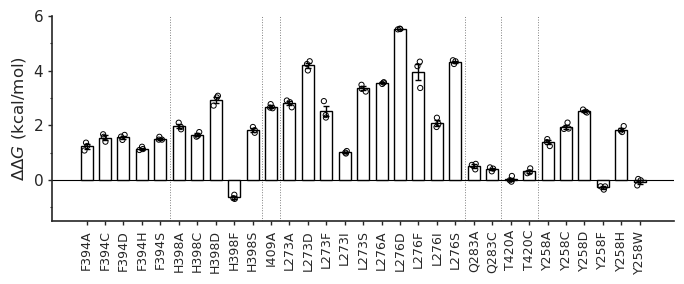

In [172]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# ---------- style ----------
mpl.rcParams['font.family']     = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['pdf.fonttype']    = 42      # keep text editable in Illustrator
mpl.rcParams['ps.fonttype']     = 42

fts  = 12
YCAP = 6.0

x = np.arange(len(stat))

fig, ax = plt.subplots(figsize=(7, 3))

# hollow bars, black outline
ax.bar(x, stat['mean'], yerr=stat['sem'],
       facecolor='white', edgecolor='black', linewidth=1.0, width=0.65,
       error_kw=dict(ecolor='black', elinewidth=1.0, capthick=1.0, capsize=2.5),
       zorder=2)

# open circles = the three replica means
rng = np.random.default_rng(0)
for rep in sub.columns:
    xj = x + rng.uniform(-0.14, 0.14, size=len(x))
    ax.scatter(xj, sub[rep].values, s=14,
               facecolors='none', edgecolors='black', linewidths=0.7, zorder=3)

ax.axhline(0, color='black', linewidth=0.8, zorder=1)

# mutation labels
ax.set_xticks(x)
ax.set_xticklabels(stat['label'], rotation=90, fontsize=fts - 3)

ax.set_ylabel(r'$\Delta\Delta G$ (kcal/mol)', fontsize=fts)
ax.tick_params(axis='y', labelsize=fts - 1)
ax.tick_params(width=1.0, length=3)

for s in ax.spines.values():
    s.set_linewidth(1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# WT-residue group separators
for b in np.where(stat['wt'].values[1:] != stat['wt'].values[:-1])[0]:
    ax.axvline(b + 0.5, color='grey', linewidth=0.7, linestyle=':', zorder=0)

# cap
ax.set_ylim(-1.5, YCAP)

# after ax.set_ylim(-1.5, YCAP)

ax.yaxis.set_major_locator(MultipleLocator(2))     # majors at -2, 0, 2, 4, 6
ax.yaxis.set_minor_locator(AutoMinorLocator(2))    # one minor between each pair

ax.tick_params(axis='y', which='major', labelsize=fts - 1, width=1.0, length=3)
ax.tick_params(axis='y', which='minor', width=0.8, length=1.8)
ax.tick_params(axis='x', which='minor', bottom=False)   # no minors on the x axis

over = stat[(stat['mean'] + stat['sem']) > YCAP]
for idx in over.index:
    ax.text(stat.index.get_loc(idx), YCAP * 0.97, '▲',
            ha='center', va='top', fontsize=fts - 5, color='black')

if len(over):
    print(f'  [note] {len(over)} bar(s) exceed {YCAP} kcal/mol:')
    print(over[['label', 'mean', 'sem']].round(3).to_string())

from matplotlib.ticker import AutoMinorLocator, MultipleLocator

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ddG_across_replicas_bw.png', dpi=600, bbox_inches='tight')
plt.savefig(f'{OUTPUT_DIR}/ddG_across_replicas_bw.pdf', bbox_inches='tight')   # vector for Illustrator
plt.show()

          label   mean     sd    sem  n_rep
mutation                                   
HQ57A     H398A  1.962  0.123  0.071      3
HQ57C     H398C  1.652  0.089  0.051      3
YA208A    Y258A  1.374  0.127  0.073      3
YA208C    Y258C  1.950  0.130  0.075      3
YA208D    Y258D  2.515  0.056  0.032      3
YA208F    Y258F -0.273  0.068  0.039      3
YA208H    Y258H  1.845  0.113  0.065      3
YA208W    Y258W -0.059  0.125  0.072      3


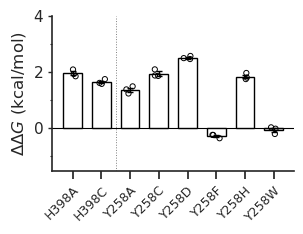

In [180]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ---------- style ----------
mpl.rcParams['font.family']     = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['pdf.fonttype']    = 42
mpl.rcParams['ps.fonttype']     = 42

fts  = 12
YCAP = 4.0

SELECT = ['H398A', 'H398C', 'Y258A', 'Y258C', 'Y258D', 'Y258F', 'Y258H', 'Y258W']

# ---------- subset, preserving SELECT order ----------
lab2idx = {lab: idx for idx, lab in stat['label'].items()}

missing = [l for l in SELECT if l not in lab2idx]
if missing:
    print(f'  [warn] not found in stat: {missing}')

keep = [lab2idx[l] for l in SELECT if l in lab2idx]
sel  = stat.loc[keep]
sub_sel = sub.loc[keep]                       # per-replica means for the same rows

print(sel[['label', 'mean', 'sd', 'sem', 'n_rep']].round(3).to_string())

# ---------- plot ----------
x = np.arange(len(sel))

fig, ax = plt.subplots(figsize=(3.2, 2.5))

ax.bar(x, sel['mean'], yerr=sel['sem'],
       facecolor='white', edgecolor='black', linewidth=1.0, width=0.65,
       error_kw=dict(ecolor='black', elinewidth=1.0, capthick=1.0, capsize=2.5),
       zorder=2)

rng = np.random.default_rng(0)
for rep in sub_sel.columns:
    xj = x + rng.uniform(-0.14, 0.14, size=len(x))
    ax.scatter(xj, sub_sel[rep].values, s=14,
               facecolors='none', edgecolors='black', linewidths=0.7, zorder=3)

ax.axhline(0, color='black', linewidth=0.8, zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(sel['label'], rotation=90, fontsize=fts - 3)
ax.set_ylabel(r'$\Delta\Delta G$ (kcal/mol)', fontsize=fts)

ax.set_ylim(-1.5, YCAP)
ax.yaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='y', which='major', labelsize=fts - 1, width=1.0, length=3)
ax.tick_params(axis='y', which='minor', width=0.8, length=1.8)
ax.tick_params(axis='x', which='minor', bottom=False)
ax.set_xticks(x)
ax.set_xticklabels(sel['label'], rotation=45, ha='right',
                   rotation_mode='anchor', fontsize=fts - 3)

for s in ax.spines.values():
    s.set_linewidth(1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# group separator between H398 and L273 blocks
for b in np.where(sel['label'].str[:4].values[1:] != sel['label'].str[:4].values[:-1])[0]:
    ax.axvline(b + 0.5, color='grey', linewidth=0.7, linestyle=':', zorder=0)

# mark anything clipped by the cap
over = sel[(sel['mean'] + sel['sem']) > YCAP]
for idx in over.index:
    ax.text(list(sel.index).index(idx), YCAP * 0.97, '▲',
            ha='center', va='top', fontsize=fts - 5, color='black')
if len(over):
    print(f'  [note] {len(over)} bar(s) exceed {YCAP}:')
    print(over[['label', 'mean', 'sem']].round(3).to_string())

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ddG_Fig7C.png', dpi=600, bbox_inches='tight')
plt.savefig(f'{OUTPUT_DIR}/ddG_Fig7C.pdf', bbox_inches='tight')
plt.show()

          label   mean     sd    sem  n_rep
mutation                                   
IQ68A     I409A  2.683  0.081  0.047      3
LA223D    L273D  4.198  0.172  0.100      3


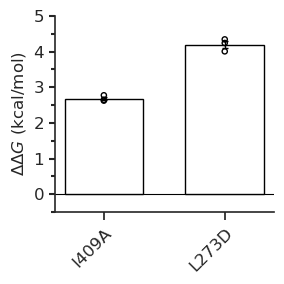

In [196]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator

# ---------- style ----------
mpl.rcParams['font.family']     = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
mpl.rcParams['pdf.fonttype']    = 42
mpl.rcParams['ps.fonttype']     = 42

fts  = 12
YCAP = 5.0

SELECT = ['I409A', 'L273D']

# ---------- subset, preserving SELECT order ----------
lab2idx = {lab: idx for idx, lab in stat['label'].items()}

missing = [l for l in SELECT if l not in lab2idx]
if missing:
    print(f'  [warn] not found in stat: {missing}')

keep = [lab2idx[l] for l in SELECT if l in lab2idx]
sel  = stat.loc[keep]
sub_sel = sub.loc[keep]                       # per-replica means for the same rows

print(sel[['label', 'mean', 'sd', 'sem', 'n_rep']].round(3).to_string())

# ---------- plot ----------
x = np.arange(len(sel))

fig, ax = plt.subplots(figsize=(3., 3.))

ax.bar(x, sel['mean'], yerr=sel['sem'],
       facecolor='white', edgecolor='black', linewidth=1.0, width=0.65,
       error_kw=dict(ecolor='black', elinewidth=1.0, capthick=1.0, capsize=2.5),
       zorder=2)

rng = np.random.default_rng(0)

ax.axhline(0, color='black', linewidth=0.8, zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(sel['label'], rotation=90, fontsize=fts - 3)
ax.set_ylabel(r'$\Delta\Delta G$ (kcal/mol)', fontsize=fts)

ax.set_ylim(-.5, YCAP)
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(axis='y', which='major', labelsize=fts, width=1.5, length=4)
ax.tick_params(axis='y', which='minor', width=1.5, length=3)
ax.tick_params(axis='x', which='minor', bottom=False, width=2)
ax.set_xticks(x)
ax.set_xticklabels(sel['label'], rotation=45, ha='right',
                   rotation_mode='anchor', fontsize=fts)

for s in ax.spines.values():
    s.set_linewidth(1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for rep in sub_sel.columns:
    ax.scatter(x, sub_sel[rep].values, s=14,
               facecolors='none', edgecolors='black', linewidths=1., zorder=3)
    
# # group separator between H398 and L273 blocks
# for b in np.where(sel['label'].str[:4].values[1:] != sel['label'].str[:4].values[:-1])[0]:
#     ax.axvline(b + 0.5, color='grey', linewidth=0.7, linestyle=':', zorder=0)

# mark anything clipped by the cap
over = sel[(sel['mean'] + sel['sem']) > YCAP]
for idx in over.index:
    ax.text(list(sel.index).index(idx), YCAP * 0.97, '▲',
            ha='center', va='top', fontsize=fts, color='black')
if len(over):
    print(f'  [note] {len(over)} bar(s) exceed {YCAP}:')
    print(over[['label', 'mean', 'sem']].round(3).to_string())

plt.tight_layout()
plt.savefig(f'Manuscript/Raw/Fig6F/ddG_Fig6F.png', dpi=600, bbox_inches='tight')
plt.savefig(f'Manuscript/Raw/Fig6F/ddG_Fig6F.pdf', bbox_inches='tight')
plt.show()